# Ethical Considerations in AI-Assisted Decision-Making

This notebook is written for **business and analytics students**, not programmers. The code is a **toy hiring pipeline** designed to make a serious point vivid: **fairness is not automatic**, and **optimization follows whatever objective you give it**.

This notebook demonstrates how prescriptive models — especially those that incorporate AI/ML — can encode and amplify unfairness, and how to identify and address those risks.

Understanding this is critical because:
- **Every prescriptive model encodes values** — through objectives, constraints, and data
- **AI amplifies this risk:** ML learns regularities from history, including historical injustice
- **Speed without reflection is dangerous:** recommendations scale faster than oversight if teams are not careful
- **"The algorithm decided" is never an acceptable explanation** — accountability stays with people and organizations

**How to read the results:** focus on **allocation percentages** across groups with equal underlying qualifications in this teaching example — that mismatch is the ethical alarm bell.


## Key Concepts

**AI-specific ethical risks:**
- **Bias in training data:** models absorb historical patterns of who was selected, promoted, or rewarded
- **Over-reliance on AI:** humans stop asking hard questions because the tool is fast
- **Opacity:** if you cannot explain or contest a decision, fairness and governance break down
- **Speed without reflection:** automated workflow is not the same as responsible workflow

**Risks that apply even without AI:**
- **Objective choice:** what you maximize becomes what you reward
- **Constraint omission:** leaving fairness out is itself a value choice, not neutrality
- **Model authority:** hiding behind math is still an ethical failure

**Four-stage ethical audit (you will see it applied):**
1. Before modeling — who is affected, whose voice is missing?
2. During modeling — what values are embedded in objective/constraints?
3. After modeling — could a affected person understand and contest the outcome?
4. AI-specific — disparate impact testing and data lineage


## Scenario: AI-Assisted Hiring

A company uses an ML model to score job applicants and an optimization model to allocate interview slots.

**The pipeline:**
1. Historical hiring data → ML model learns who gets hired
2. ML model scores new applicants
3. Optimization allocates a fixed number of interview slots to maximize total applicant score

**The problem:** The historical hiring data reflects five years of past decisions — and those decisions were not made fairly. We will see what happens when a biased pipeline is deployed without ethical review, and how adding a fairness constraint changes the outcome.

## Step 1: Install Required Packages

**What you are doing:** installing `pulp` to solve a small binary selection optimization (who gets an interview slot), plus plotting/table libraries.

This notebook uses optimization as a **decision rule** — "pick up to 25 candidates to maximize total score" — which is how many allocation systems are actually implemented.


In [1]:
%pip install numpy matplotlib pandas pulp -q


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Step 2: Import Libraries

**Standard imports** for tables (`pandas`), repeatable randomness (`numpy`), plots (`matplotlib`), and optimization (`pulp`).

**`np.random.seed(42)`** keeps the synthetic biased history and applicant pool stable for grading and discussion.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pulp import LpMaximize, LpProblem, LpVariable, LpInteger, lpSum, value, PULP_CBC_CMD
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## Step 3: The Historical Data Contains Bias

**Story:** we create synthetic records for three groups with **similar qualification distributions** but **different historical hire rates**. That gap is the stand-in for systemic bias in who was selected in the past.

**What the code is doing:** for each applicant record, it stores group label, a qualification draw, and a hire/no-hire outcome drawn using group-specific probabilities.

**After you run it:** confirm with your eyes that average qualifications are close, but hire rates differ — that sets up the next step (ML inherits the pattern).


In [3]:
# === HISTORICAL HIRING DATA ===
# Three applicant groups, all equally qualified on objective measures
n_per_group = 500

np.random.seed(42)
historical_data = []

group_config = [
    # (group_label, mean_qualification_score, historical_hire_rate)
    ('Group A', 75, 0.72),   # historically hired most often
    ('Group B', 75, 0.55),   # qualified equally, hired less often
    ('Group C', 75, 0.41),   # qualified equally, hired least often
]

for group, q_mean, hire_rate in group_config:
    quals   = np.random.normal(q_mean, 10, n_per_group).clip(0, 100)
    # Historical hiring was correlated with group membership, not just qualifications
    hired   = np.random.binomial(1, hire_rate, n_per_group)
    for q, h in zip(quals, hired):
        historical_data.append({'group': group, 'qualification': round(q, 1), 'hired': h})

df_hist = pd.DataFrame(historical_data)

print('=== HISTORICAL HIRING DATA SUMMARY ===')
summary = df_hist.groupby('group').agg(
    n_applicants=('hired', 'count'),
    mean_qualification=('qualification', 'mean'),
    hire_rate=('hired', 'mean')
).reset_index()
summary['hire_rate'] = (summary['hire_rate'] * 100).round(1).astype(str) + '%'
summary['mean_qualification'] = summary['mean_qualification'].round(1)
print(summary.to_string(index=False))
print()
print('Observation: all groups have nearly identical average qualifications.')
print('The different hire rates reflect historical bias, not differences in capability.')

=== HISTORICAL HIRING DATA SUMMARY ===
  group  n_applicants  mean_qualification hire_rate
Group A           500                75.0     71.2%
Group B           500                75.7     53.4%
Group C           500                74.7     43.0%

Observation: all groups have nearly identical average qualifications.
The different hire rates reflect historical bias, not differences in capability.


## Step 4: The ML Model Learns — and Inherits the Bias

**Story:** in real life, an ML model might ingest many features. Here we simulate the *effect* of biased history: scores drift by group even when qualifications are similar.

**What the code is doing:** constructs a new applicant pool, then sets `ml_score` using qualifications plus a **group-based shift** (a teaching stand-in for "the model learned the wrong signal").

**After you run it:** the grouped averages should show **equal-ish qualifications** but **unequal average scores** — that is the disparate scoring problem in miniature.


In [4]:
# === ML MODEL: SIMULATING BIASED SCORES ===
# In a real system, the ML model would be trained on historical features.
# Here we simulate the effect: the model's scores reflect historical hiring patterns,
# not just objective qualifications.

# New applicant pool: 90 candidates, 30 per group, all equally qualified
n_new = 30
new_applicants = []

# Bias weights the ML model learned from historical data
group_bias = {'Group A': 12, 'Group B': 0, 'Group C': -10}

for group, q_mean, _ in group_config:
    quals = np.random.normal(q_mean, 8, n_new).clip(40, 100)
    # Biased ML score = qualification + group-based bias learned from history
    ml_scores = quals + group_bias[group] + np.random.normal(0, 3, n_new)
    ml_scores = ml_scores.clip(0, 100)
    for q, s in zip(quals, ml_scores):
        new_applicants.append({
            'group':         group,
            'qualification': round(q, 1),
            'ml_score':      round(s, 1),
        })

df_new = pd.DataFrame(new_applicants)

print('=== NEW APPLICANT POOL: QUALIFICATION vs. ML SCORE ===')
score_summary = df_new.groupby('group').agg(
    mean_qualification=('qualification', 'mean'),
    mean_ml_score=('ml_score', 'mean')
).reset_index()
score_summary['mean_qualification'] = score_summary['mean_qualification'].round(1)
score_summary['mean_ml_score']      = score_summary['mean_ml_score'].round(1)
print(score_summary.to_string(index=False))
print()
print('Problem: qualifications are equal across groups.')
print('But ML scores differ substantially — because the model learned historical bias.')

=== NEW APPLICANT POOL: QUALIFICATION vs. ML SCORE ===
  group  mean_qualification  mean_ml_score
Group A                78.0           89.9
Group B                72.9           72.8
Group C                75.5           65.0

Problem: qualifications are equal across groups.
But ML scores differ substantially — because the model learned historical bias.


## Step 5: The Optimization Allocates Interviews — Amplifying the Bias

**Story:** the organization allocates **25** interview slots to maximize total ML score. The optimizer is doing exactly what we asked mathematically — and that can still be unfair socially.

**What `run_optimization` does:**
- Binary decision for each applicant: selected or not
- Exactly `slots` selections
- Objective: maximize sum of selected applicants' scores

**After you run it:** you should see interviews concentrated in the group with inflated scores — despite equal qualifications in the teaching setup.


In [5]:
# === OPTIMIZATION WITHOUT FAIRNESS CONSTRAINTS ===
total_slots = 25
n_applicants = len(df_new)

def run_optimization(df, slots, fairness_min=None):
    model = LpProblem('Interview_Allocation', LpMaximize)
    select = [LpVariable(f'x_{i}', cat='Binary') for i in range(len(df))]
    
    # Objective: maximize total ML score
    model += lpSum(df['ml_score'].iloc[i] * select[i] for i in range(len(df)))
    
    # Constraint: exactly 'slots' interviews total
    model += lpSum(select) == slots, 'Total_Slots'
    
    # Optional fairness constraint: minimum interviews per group
    if fairness_min is not None:
        for group in df['group'].unique():
            group_idx = df.index[df['group'] == group].tolist()
            # reindex to position
            pos = [df.index.get_loc(i) for i in group_idx]
            model += lpSum(select[p] for p in pos) >= fairness_min, f'Min_{group}'
    
    model.solve(PULP_CBC_CMD(msg=0))
    
    df_result = df.copy().reset_index(drop=True)
    df_result['selected'] = [int(value(select[i])) for i in range(len(df))]
    return df_result, value(model.objective)

df_result_no_fairness, obj_no_fairness = run_optimization(df_new.reset_index(drop=True), total_slots)

selection_no_fairness = df_result_no_fairness.groupby('group')['selected'].sum()
print('=== OPTIMIZATION RESULT: NO FAIRNESS CONSTRAINT ===')
print(f'Total interview slots: {total_slots}')
print()
print('Interviews allocated by group:')
for group, count in selection_no_fairness.items():
    pct = count / total_slots * 100
    print(f'  {group}: {count:>3} interviews ({pct:.0f}% of total)')
print()
print('Each group had 30 equally-qualified applicants.')
print('The optimization allocated interviews almost entirely to Group A')
print('because the biased ML scores made Group A appear most qualified.')
print('This is discrimination — encoded in an algorithm.')

=== OPTIMIZATION RESULT: NO FAIRNESS CONSTRAINT ===
Total interview slots: 25

Interviews allocated by group:
  Group A:  24 interviews (96% of total)
  Group B:   0 interviews (0% of total)
  Group C:   1 interviews (4% of total)

Each group had 30 equally-qualified applicants.
The optimization allocated interviews almost entirely to Group A
because the biased ML scores made Group A appear most qualified.
This is discrimination — encoded in an algorithm.


## Step 6: Apply the Ethical Audit Framework

**What this step is doing:** structured questions that turn ethics from vibes into reviewable checkpoints.

As you read each stage, connect it to your own domain (hiring, lending, scheduling, pricing): **who might be harmed**, and **what evidence would you demand** before launch?


In [6]:
# === FOUR-STAGE ETHICAL AUDIT ===
print('=== ETHICAL AUDIT: AI-ASSISTED HIRING SYSTEM ===')
print()

audit = [
    {
        'stage': 'Before modeling',
        'question': 'Who is affected? Whose perspective is missing?',
        'finding': 'Applicants from all groups are affected. Groups B and C were'
                   ' underrepresented in the historical data used to train the ML model.',
        'action':  'Audit historical data for representation before training.'
    },
    {
        'stage': 'During modeling',
        'question': 'What values are embedded in the objective and constraints?',
        'finding': 'The objective (maximize ML score) treats historical hiring patterns'
                   ' as a proxy for merit. No fairness constraints were included.',
        'action':  'Add minimum allocation constraints per group. Redefine score to'
                   ' weight objective qualifications more heavily than group-correlated features.'
    },
    {
        'stage': 'After modeling',
        'question': 'Can the recommendation be explained to those it affects?',
        'finding': 'A rejected Group C applicant with high qualifications cannot be told'
                   ' why they were not selected without revealing group-based scoring.',
        'action':  'Ensure explanations reference only objective qualifications.'
    },
    {
        'stage': 'AI-specific check',
        'question': 'Where could bias enter? Has disparate impact been tested?',
        'finding': 'The ML model was trained on biased historical data. Group membership'
                   ' effectively functions as a feature even if not explicitly included.',
        'action':  'Test for disparate impact: if equally-qualified candidates'
                   ' are selected at different rates by group, the model is discriminatory.'
    },
]

for item in audit:
    print(f"Stage: {item['stage']}")
    print(f"  Question: {item['question']}")
    print(f"  Finding:  {item['finding']}")
    print(f"  Action:   {item['action']}")
    print()

=== ETHICAL AUDIT: AI-ASSISTED HIRING SYSTEM ===

Stage: Before modeling
  Question: Who is affected? Whose perspective is missing?
  Finding:  Applicants from all groups are affected. Groups B and C were underrepresented in the historical data used to train the ML model.
  Action:   Audit historical data for representation before training.

Stage: During modeling
  Question: What values are embedded in the objective and constraints?
  Finding:  The objective (maximize ML score) treats historical hiring patterns as a proxy for merit. No fairness constraints were included.
  Action:   Add minimum allocation constraints per group. Redefine score to weight objective qualifications more heavily than group-correlated features.

Stage: After modeling
  Question: Can the recommendation be explained to those it affects?
  Finding:  A rejected Group C applicant with high qualifications cannot be told why they were not selected without revealing group-based scoring.
  Action:   Ensure explanatio

## Step 7: Add a Fairness Constraint

**Story:** one simple policy response is a **minimum allocation** per group. This does not solve every fairness problem in the real world, but it makes a key point: **fairness constraints change who gets opportunity** — and usually change the objective value.

**What the code does:** reruns the optimizer with an additional constraint: each group must receive at least `fairness_minimum` interviews.

**How to read the charts:** compare bar heights across groups with and without the constraint; the red dashed line marks the minimum policy threshold.

**Important:** whether this constraint is appropriate legally and ethically is a **management and governance** question — the notebook shows the *mechanism*, not your organization's final policy.


=== COMPARISON: WITHOUT vs. WITH FAIRNESS CONSTRAINT ===
Total slots: 25 | Fairness minimum per group: 7

Group        Without Fairness   With Fairness
----------------------------------------------
Group A                24 slots            11 slots
Group B                 0 slots             7 slots
Group C                 1 slots             7 slots

Objective value without fairness: 2317.1
Objective value with fairness:    2172.5

The objective value decreases slightly with the fairness constraint.
This is the cost of fairness — and it is a policy decision whether to pay it.
The model cannot make that decision. The organization must.


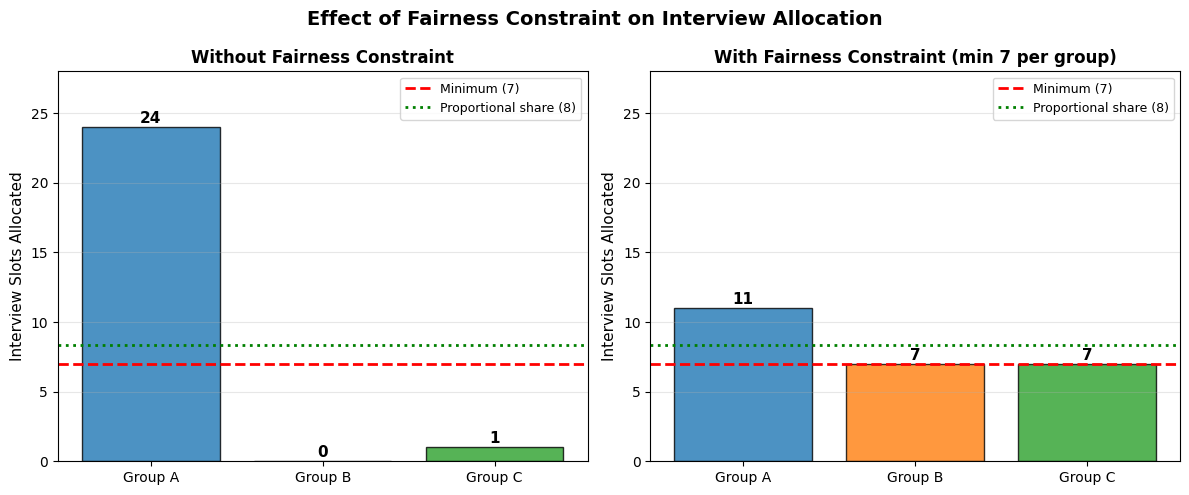

In [7]:
# === OPTIMIZATION WITH FAIRNESS CONSTRAINT ===
# Minimum: each group gets at least 7 of 25 slots (roughly proportional to group size)
fairness_minimum = 7

df_result_fair, obj_fair = run_optimization(
    df_new.reset_index(drop=True), total_slots, fairness_min=fairness_minimum
)

selection_fair = df_result_fair.groupby('group')['selected'].sum()

print('=== COMPARISON: WITHOUT vs. WITH FAIRNESS CONSTRAINT ===')
print(f'Total slots: {total_slots} | Fairness minimum per group: {fairness_minimum}')
print()
print(f"{'Group':<10} {'Without Fairness':>18} {'With Fairness':>15}")
print('-' * 46)
for group in ['Group A', 'Group B', 'Group C']:
    n_no  = selection_no_fairness.get(group, 0)
    n_yes = selection_fair.get(group, 0)
    print(f"{group:<10} {n_no:>14} slots    {n_yes:>10} slots")
print()
print(f'Objective value without fairness: {obj_no_fairness:.1f}')
print(f'Objective value with fairness:    {obj_fair:.1f}')
print()
print('The objective value decreases slightly with the fairness constraint.')
print('This is the cost of fairness — and it is a policy decision whether to pay it.')
print('The model cannot make that decision. The organization must.')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
groups = ['Group A', 'Group B', 'Group C']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for ax, (label, sel) in zip(axes, [
    ('Without Fairness Constraint', selection_no_fairness),
    ('With Fairness Constraint (min 7 per group)', selection_fair)
]):
    counts = [sel.get(g, 0) for g in groups]
    bars = ax.bar(groups, counts, color=colors, alpha=0.8, edgecolor='black')
    ax.axhline(fairness_minimum, color='red', linestyle='--', lw=2,
               label=f'Minimum ({fairness_minimum})')
    ax.axhline(total_slots / 3, color='green', linestyle=':', lw=2,
               label=f'Proportional share ({total_slots/3:.0f})')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylabel('Interview Slots Allocated', fontsize=11)
    ax.set_ylim(0, 28)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(count), ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Effect of Fairness Constraint on Interview Allocation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Key Takeaways (Outro)

1. **Historical bias becomes future recommendations** when models learn from historical outcomes — even if sensitive attributes are not "officially" typed into a spreadsheet column.

2. **Constraint omission is not neutral.** If you optimize only "total score," you implicitly say score is the only thing that matters unless you add other safeguards.

3. **Ethical review should happen before scale.** After harm, explanations feel like excuses.

4. **Fairness mechanisms have costs in the objective** — that cost is exactly why organizations argue about values, not just math.

5. **Accountability is human.** If a stakeholder cannot get a sensible explanation, the system is not ready.

**This completes the Lesson 11 notebook series.** You have worked through Monte Carlo simulation, optimize-then-simulate, ML-fed prescriptive pipelines, generative AI partnership with validation, and ethical responsibility in AI-assisted decision systems.
